# Unit 1: Numerical Interpolation (Connect the Dots)
**Date:** Jan 24 (Saturday)

**Topic:** Lagrange Polynomials & Cubic Splines (`scipy.interpolate`)

## 1. Introduction: Interpolation vs. Fitting
In experimental physics, we collect discrete data points $(x_i, y_i)$. often, we need to know the value of $y$ at some $x$ *between* our data points.

* **Curve Fitting (Regression):** We assume a model (e.g., a line $y=mx+c$) and find the "best fit." The line might not pass through *any* specific point.
* **Interpolation:** We demand a curve that passes **exactly** through every single data point.


## 2. Lagrange Interpolation (The Polynomial Approach)
The simplest idea is: "If I have $N$ points, there is a unique polynomial of degree $N-1$ that hits them all."
For example, 2 points define a line (degree 1). 3 points define a parabola (degree 2).

The formula is:
$$P(x) = \sum_{j=0}^{k} y_j L_j(x)$$
Where $L_j(x)$ are the "Lagrange Basis Polynomials" designed such that $L_j(x_j) = 1$ and $L_j(x_i) = 0$ for all other points.

**The Catch:** High-degree polynomials are **unstable**. They tend to oscillate wildly between points (Runge's Phenomenon).

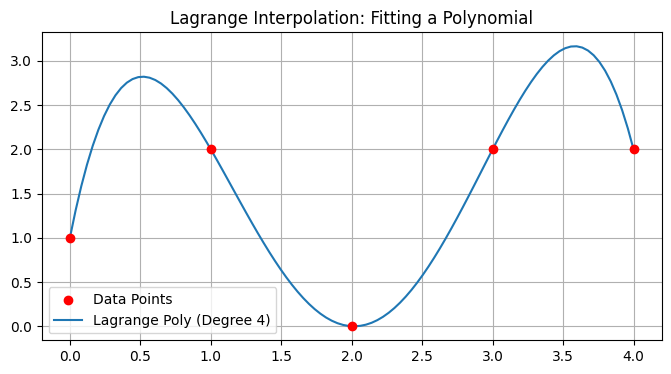

Polynomial Coefficients:
         4         3         2
-0.5417 x + 4.417 x - 10.96 x + 8.083 x + 1


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

# 1. Create 5 data points (Sparse data)
x_data = np.array([0, 1, 2, 3, 4])
y_data = np.array([1, 2, 0, 2, 2])

# 2. Compute Lagrange Polynomial
# This returns a polynomial object (like p(x) = -0.5x^4 + ...)
poly = lagrange(x_data, y_data)

# print(poly)


# 3. Generate a dense grid to visualize the curve
x_dense = np.linspace(0, 4, 100)
y_lagrange = poly(x_dense)

# Plotting
plt.figure(figsize=(8, 4))
plt.scatter(x_data, y_data, color='red', label='Data Points', zorder=5)
plt.plot(x_dense, y_lagrange, label=f'Lagrange Poly (Degree {len(x_data)-1})')
plt.title("Lagrange Interpolation: Fitting a Polynomial")
plt.legend()
plt.grid(True)
plt.show()

print(f"Polynomial Coefficients:\n{poly}")

## 3. Cubic Splines (The Smooth Approach)
Instead of one giant polynomial that wiggles uncontrollably, **Splines** use many small polynomials glued together.
* **Piecewise:** Between point A and point B, we use a cubic equation ($ax^3 + bx^2 + cx + d$).
* **Smooth:** We ensure the curve, its slope (1st derivative), and its curvature (2nd derivative) match perfectly at the junctions (knots).

This mimics a flexible ruler ("spline") used by draftsmen. It is the gold standard for interpolation in Physics.

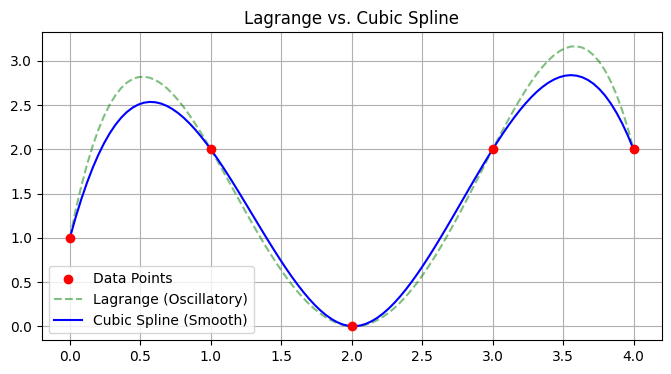

In [6]:
from scipy.interpolate import CubicSpline

# Using the same data
# CubicSpline calculates the coefficients for the piecewise segments
cs = CubicSpline(x_data, y_data)

y_spline = cs(x_dense)

plt.figure(figsize=(8, 4))
plt.scatter(x_data, y_data, color='red', label='Data Points', zorder=5)
plt.plot(x_dense, y_lagrange, 'g--', alpha=0.5, label='Lagrange (Oscillatory)')
plt.plot(x_dense, y_spline, 'b-', label='Cubic Spline (Smooth)')
plt.title("Lagrange vs. Cubic Spline")
plt.legend()
plt.grid(True)
plt.show()

## Problem 1: The Missing Sensor Data
**Context:** You have a temperature sensor that records data every hour. However, the sensor malfunctioned at **2:30 PM** (t=2.5). You need to estimate the temperature at that exact time based on the surrounding hours.

**Data:**
* Time: 0, 1, 2, 3, 4, 5 hours
* Temp: 20, 22, 24, 23, 21, 18 degrees

In [7]:
import numpy as np
from scipy.interpolate import CubicSpline

t_hours = np.array([0, 1, 2, 3, 4, 5])
temps   = np.array([20, 22, 24, 23, 21, 18])

# TODO: Create a CubicSpline object using the data above
spline_model = CubicSpline(t_hours, temps)

lagrange_model = lagrange(t_hours, temps)

# TODO: Use the model to predict temperature at t = 2.5
temp_2_30 = spline_model(2.5)
temp_lag = lagrange_model(2.5)

print(f"Estimated Temp at 2:30 PM: {temp_2_30:.4f} C")
print(f"Estimated Temp at 2:30 PM: {temp_lag:.4f} C")


# --- AUTO-GRADER ---
# Linear average would be (24+23)/2 = 23.5.
# A smooth curve should be slightly higher because the peak is around t=2.
if spline_model is not ...:
    assert 23.5 < temp_2_30 < 24.5, "Result seems off. Did you evaluate at 2.5?"
    print("✅ Prediction looks reasonable!")

Estimated Temp at 2:30 PM: 23.7875 C
Estimated Temp at 2:30 PM: 23.7852 C
✅ Prediction looks reasonable!


## Problem 2: Runge's Phenomenon (Why Polynomials Fail)
**Theory:** If you try to fit a high-degree polynomial to specific functions (like a bell curve $1/(1+25x^2)$) using evenly spaced points, the edges of the polynomial will swing wildly to infinity.

**Task:** Observe the disaster of using Lagrange on 11 points.

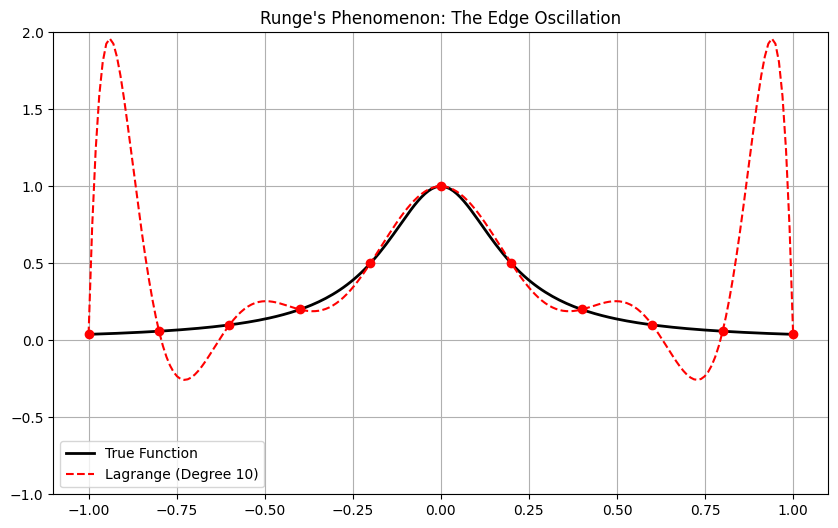

True Value at 0.9: 0.0471
Lagrange Value at 0.9: 1.5787
Error: 1.5317

✅ Observation Confirmed: The Lagrange polynomial fails miserably at the edges!


In [ ]:
def runge_func(x):
    return 1 / (1 + 25 * x**2)

# 11 points evenly spaced from -1 to 1
x_runge = np.linspace(-1, 1, 11)
y_runge = runge_func(x_runge)

# Dense grid for plotting truth
x_truth = np.linspace(-1, 1, 200)
y_truth = runge_func(x_truth)

# TODO: Create a Lagrange polynomial 'poly_runge' from x_runge and y_runge
# Use lagrange(x, y)
poly_runge = ______(x_runge, y_runge)

# Evaluate on the dense grid
y_poly_eval = poly_runge(x_truth)

# Plotting to see the horror
plt.figure(figsize=(10, 6))
plt.plot(x_truth, y_truth, 'k-', linewidth=2, label="True Function")
plt.scatter(x_runge, y_runge, color='red', zorder=5)
plt.plot(x_truth, y_poly_eval, 'r--', label="Lagrange (Degree 10)")
plt.ylim(-1, 2) # Limit y-axis so we don't see infinite spikes
plt.title("Runge's Phenomenon: The Edge Oscillation")
plt.legend()
plt.grid(True)
plt.show()

# --- AUTO-GRADER ---
# Check the error at x = 0.9 (near the edge)
true_val = runge_func(0.9)
poly_val = poly_runge(0.9)
error = abs(true_val - poly_val)

print(f"True Value at 0.9: {true_val:.4f}")
print(f"Lagrange Value at 0.9: {poly_val:.4f}")
print(f"Error: {error:.4f}")

if error > 0.1:
    print("\n✅ Observation Confirmed: The Lagrange polynomial fails miserably at the edges!")
else:
    print("Something went wrong with the setup.")

## Summary
1.  **Interpolation** passes through every point.
2.  **Lagrange (`scipy.interpolate.lagrange`):** Good for 3-4 points. Dangerous for many points (Oscillations).
3.  **Cubic Spline (`scipy.interpolate.CubicSpline`):** The standard choice. Smooth, stable, and handles many points well.